<a href="https://colab.research.google.com/github/lucy980509/Wafer-Defect-Classification/blob/main/notebooks/Wafer_Defect_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# 1. Initialize Kaggle API credentials
!mkdir -p ~/.kaggle

kaggle_config = """{
  "username": "suminsim",
  "key": "KGAT_0d4f0824c86713062bb393ab4304aaab"
}"""

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_config)

!chmod 600 ~/.kaggle/kaggle.json

# 2. Download dataset via Kaggle API
print("[INFO] Downloading wm811k-wafer-map dataset...")
!kaggle datasets download -d qingyi/wm811k-wafer-map

# 3. Extract dataset and organize directory
print("[INFO] Extracting dataset...")
!rm -rf ./wafer_data
!mkdir -p ./wafer_data
!unzip -q wm811k-wafer-map.zip -d ./wafer_data

# 4. Verify integrity of the extracted file
target_path = "./wafer_data/LSWMD.pkl"
if os.path.exists(target_path):
    print(f"[SUCCESS] Dataset is ready at: {target_path}")
else:
    print("[ERROR] Extraction failed. LSWMD.pkl not found.")

[INFO] Downloading wm811k-wafer-map dataset...
Dataset URL: https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map
License(s): CC0-1.0
100% 149M/149M [00:09<00:00, 15.8MB/s]

[INFO] Extracting dataset...
[SUCCESS] Dataset is ready at: ./wafer_data/LSWMD.pkl


In [2]:
import pandas as pd
import numpy as np

print("[INFO] Loading LSWMD.pkl into DataFrame...")
df = pd.read_pickle("./wafer_data/LSWMD.pkl")

print(f"[INFO] Dataset shape: {df.shape}")
print("[INFO] Displaying the first 5 rows:")
df.head()

[INFO] Loading LSWMD.pkl into DataFrame...
[INFO] Dataset shape: (811457, 6)
[INFO] Displaying the first 5 rows:


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [3]:
def extract_clean_label(val):
    if isinstance(val, np.ndarray) and val.size > 0:
        return val[0][0]
    return "Unlabeled"

print("[INFO] Extracting raw labels into clean text format...")
df['failureType_clean'] = df['failureType'].apply(extract_clean_label)

print("\n[INFO] Cleaned failure type distribution:")
print(df['failureType_clean'].value_counts())

[INFO] Extracting raw labels into clean text format...

[INFO] Cleaned failure type distribution:
failureType_clean
Unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [4]:
print(df.columns)

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType', 'failureType_clean'],
      dtype='object')


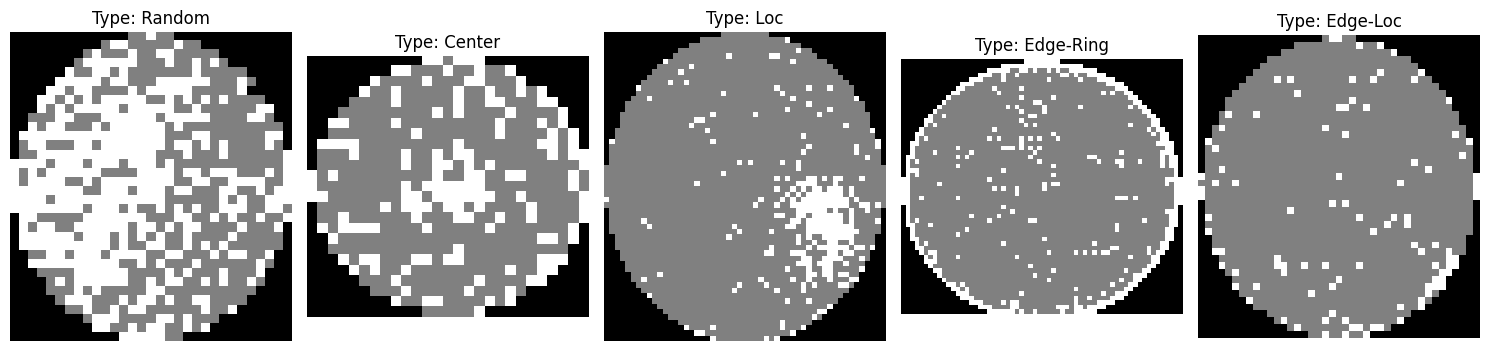

In [5]:
import matplotlib.pyplot as plt

df_defects = df[~df['failureType_clean'].isin(['Unlabeled', 'none'])]

sample_defects = df_defects.sample(5)

plt.figure(figsize=(15, 5))
for i, (idx, row) in enumerate(sample_defects.iterrows()):
    plt.subplot(1, 5, i + 1)
    plt.imshow(row['waferMap'], cmap='gray')
    plt.title(f"Type: {row['failureType_clean']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.utils import class_weight

labels = df['failureType_clean'].values

# 2. 클래스별 가중치 자동 계산
# 'balanced' 옵션을 쓰면 데이터 개수에 반비례하게 가중치를 자동으로 맞춰줍니다.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# 3. 딕셔너리 형태로 보기 좋게 만들기
class_weight_dict = dict(zip(np.unique(labels), class_weights))

print("각 불량 타입별 가중치:")
for cls, weight in class_weight_dict.items():
    print(f"{cls}: {weight:.2f}")

각 불량 타입별 가중치:
Center: 18.90
Donut: 146.21
Edge-Loc: 15.64
Edge-Ring: 8.38
Loc: 22.58
Near-full: 544.60
Random: 93.70
Scratch: 68.02
Unlabeled: 0.13
none: 0.55
